## Tâche 1 : Chargement et Exploration du Dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [32]:
# Chargement du dataset
url = "https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"
df = pd.read_csv(url, encoding='latin-1')

print(df.head(10))

# Le dataset a des colonnes supplémentaires inutiles, on ne garde que les 2 premières
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape du dataset:", df.shape)
df.head(10)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
5        NaN        NaN  
6        NaN  

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [33]:
# Distribution des classes
print("\nDistribution des classes:")
print(df['label'].value_counts())

print("\nPourcentage:")
print(df['label'].value_counts(normalize=True) * 100)


Distribution des classes:
label
ham     4825
spam     747
Name: count, dtype: int64

Pourcentage:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [34]:
# Longueur moyenne des SMS par classe
df['message_length'] = df['message'].apply(len)

print(df.groupby('label')['message_length'].describe())

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [35]:
print("SPAM")
for i, msg in enumerate(df[df['label'] == 'spam']['message'].head(5), 1):
    print(f"{i}. {msg}\n")

print("HAM")
for i, msg in enumerate(df[df['label'] == 'ham']['message'].head(5), 1):
    print(f"{i}. {msg}\n")

SPAM
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

3. WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info

HAM
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I do

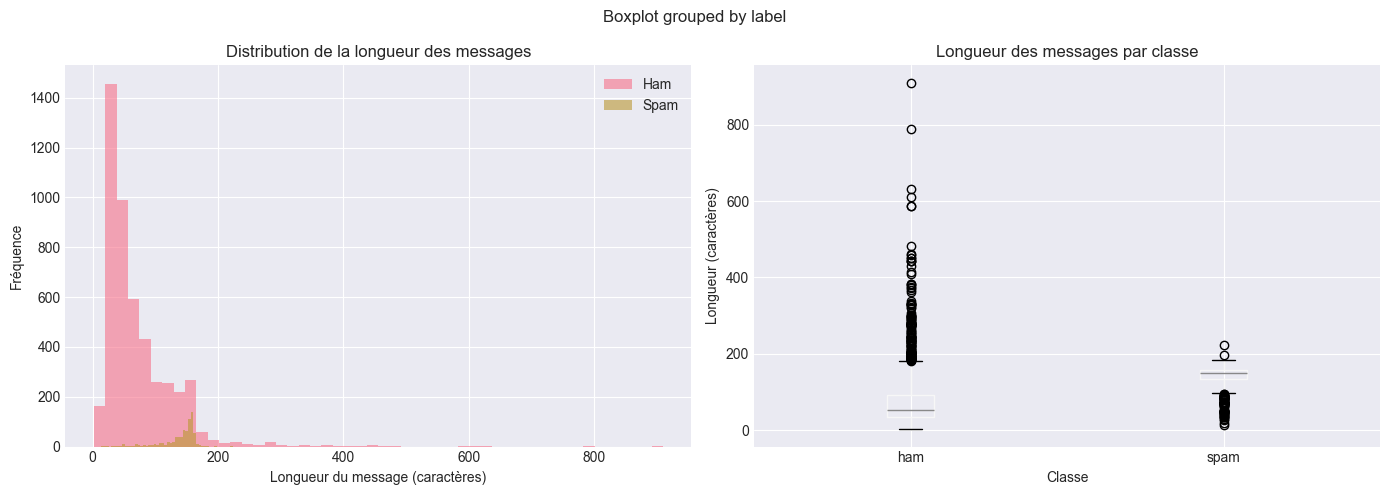

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
df[df['label'] == 'ham']['message_length'].hist(bins=50, alpha=0.6, label='Ham', ax=axes[0])
df[df['label'] == 'spam']['message_length'].hist(bins=50, alpha=0.6, label='Spam', ax=axes[0])
axes[0].set_xlabel('Longueur du message (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la longueur des messages')
axes[0].legend()

# Boxplot
df.boxplot(column='message_length', by='label', ax=axes[1])
axes[1].set_title('Longueur des messages par classe')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Longueur (caractères)')

plt.tight_layout()
plt.show()


In [37]:
# Analyse du déséquilibre
spam_count = (df['label'] == 'spam').sum()
ham_count = (df['label'] == 'ham').sum()
ratio = ham_count / spam_count

print(f"Ham: {ham_count} messages ({ham_count/len(df)*100:.1f}%)")
print(f"Spam: {spam_count} messages ({spam_count/len(df)*100:.1f}%)")
print(f"Ratio Ham/Spam: {ratio:.2f}:1")

Ham: 4825 messages (86.6%)
Spam: 747 messages (13.4%)
Ratio Ham/Spam: 6.46:1


## Tâche 2 : Préparation des Données Textuelles

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])


In [39]:
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['message']).toarray()

print(f"\nShape de X après TF-IDF: {X.shape}")
print(f"Nombre de features: {X.shape[1]}")


Shape de X après TF-IDF: (5572, 1000)
Nombre de features: 1000


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"\nTaille du set d'entraînement: {X_train.shape[0]} messages")
print(f"Taille du set de test: {X_test.shape[0]} messages")
print(f"\nProportion spam dans train: {y_train.mean()*100:.1f}%")
print(f"Proportion spam dans test: {y_test.mean()*100:.1f}%")


Taille du set d'entraînement: 4457 messages
Taille du set de test: 1115 messages

Proportion spam dans train: 13.4%
Proportion spam dans test: 13.4%


In [41]:
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

print(f"\nShape de y_train après one-hot: {y_train_cat.shape}")
print(f"\nExemple:")
print(f"Label original: {y_train[0]} -> One-hot: {y_train_cat[0]}")
print(f"Label original: {y_train[1]} -> One-hot: {y_train_cat[1]}")


Shape de y_train après one-hot: (4457, 2)

Exemple:
Label original: 0 -> One-hot: [1. 0.]
Label original: 0 -> One-hot: [1. 0.]


## Tâche 3 : Construction du MLP

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(64, activation='relu', input_shape=(1000,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax') 
])

model.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │        64,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,210 (258.63 KB)

 Trainable params: 66,210 (258.63 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:

model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## Tâche 4 : Entraînement avec Gestion du Déséquilibre

In [44]:
from sklearn.utils.class_weight import compute_class_weight

# Calcul des poids de classe pour compenser le déséquilibre
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    class_weight=class_weight_dict, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7352 - loss: 0.6691 - val_accuracy: 0.9484 - val_loss: 0.6518
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9568 - loss: 0.5846 - val_accuracy: 0.9664 - val_loss: 0.4672
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.3546 - val_accuracy: 0.9697 - val_loss: 0.2209
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9790 - loss: 0.1647 - val_accuracy: 0.9697 - val_loss: 0.1251
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9806 - loss: 0.0984 - val_accuracy: 0.9731 - val_loss: 0.1016
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9818 - loss: 0.0733 - val_accuracy: 0.9720 - val_loss: 0.0946
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9871 - loss: 0.0556 - val_accuracy: 0.9731 - val_loss: 0.0886
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9910 - loss: 0.0456 - val_accuracy: 0.9731 - val_loss

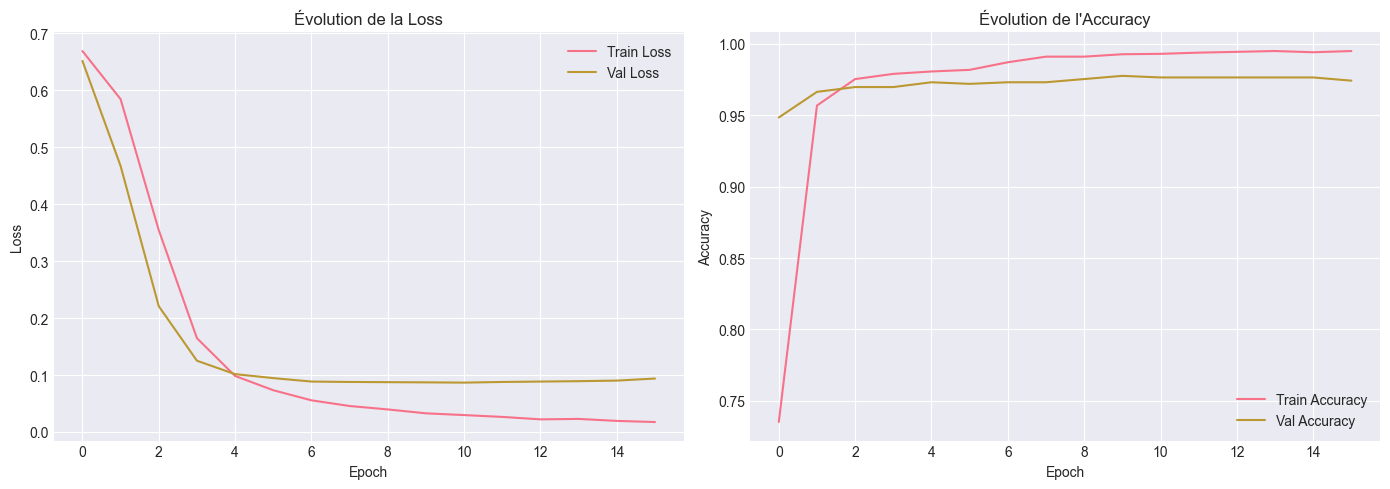

In [46]:
# Visualisation des courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Évolution de la Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Évolution de l\'Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Tâche 5 : Évaluation Détaillée

In [47]:

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Loss: 0.0752
Test Accuracy: 97.94%


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Rapport de classification détaillé
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['Ham', 'Spam'],
    digits=3
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

         Ham      0.989     0.988     0.988       966
        Spam      0.920     0.926     0.923       149

    accuracy                          0.979      1115
   macro avg      0.954     0.957     0.956      1115
weighted avg      0.979     0.979     0.979      1115



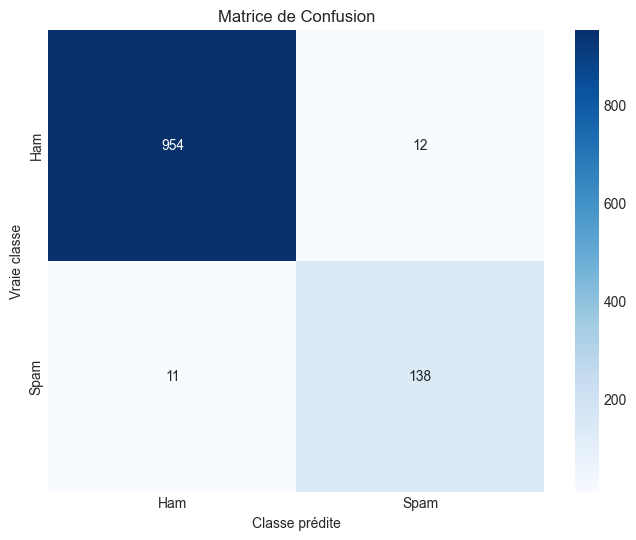

In [49]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.title('Matrice de Confusion')
plt.show()

In [50]:

errors_idx = np.where(y_pred != y_test)[0]

print(f"Nombre d'erreurs: {len(errors_idx)} sur {len(y_test)} ({len(errors_idx)/len(y_test)*100:.1f}%)")

Nombre d'erreurs: 23 sur 1115 (2.1%)


## Tâche 6 : Tester le Modèle sur de Nouveaux SMS

In [51]:
def predict_sms(message, threshold=0.5):
    # Vectorisation du message avec le même TF-IDF
    message_tfidf = tfidf.transform([message]).toarray()
    
    # Prédiction
    proba = model.predict(message_tfidf, verbose=0)[0]
    spam_proba = proba[1]
    
    # Classification avec seuil personnalisé
    is_spam = spam_proba >= threshold
    label = "SPAM" if is_spam else "HAM"
    
    return label, spam_proba

test_messages = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are you coming to dinner tonight?",
    "URGENT: Your account will be suspended. Verify your identity immediately!",
    "Can you pick up some milk on your way home?",
    "FREE entry to win a brand new iPhone! Text WIN to 12345",
    "Meeting rescheduled to 3pm tomorrow"
]

for msg in test_messages:
    label, proba = predict_sms(msg)
    print(f"[{label}] {proba*100:.1f}% - {msg[:60]}...")

[SPAM] 99.0% - Congratulations! You've won a $1000 gift card. Click here to...
[HAM] 0.0% - Hey, are you coming to dinner tonight?...
[SPAM] 83.3% - URGENT: Your account will be suspended. Verify your identity...
[HAM] 0.0% - Can you pick up some milk on your way home?...
[SPAM] 99.4% - FREE entry to win a brand new iPhone! Text WIN to 12345...
[HAM] 0.3% - Meeting rescheduled to 3pm tomorrow...


## Tâche 7 : Amélioration du Modèle (Bonus)

In [52]:
# 1. Augmenter max_features du TF-IDF
tfidf_improved = TfidfVectorizer(
    max_features=2000,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2)
)

X_improved = tfidf_improved.fit_transform(df['message']).toarray()
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y, test_size=0.2, random_state=42, stratify=y
)

y_train_imp_cat = to_categorical(y_train_imp, num_classes=2)
y_test_imp_cat = to_categorical(y_test_imp, num_classes=2)

print(f"Nouvelle shape: {X_improved.shape}")

Nouvelle shape: (5572, 2000)


In [53]:
# 2. Architecture améliorée
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(2000,)),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(2, activation='sigmoid')
])

model_improved.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_improved.summary()

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,530 (1.02 MB)

 Trainable params: 266,530 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Entraînement du modèle amélioré
history_improved = model_improved.fit(
    X_train_imp, y_train_imp_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6351 - loss: 0.6710 - val_accuracy: 0.9126 - val_loss: 0.6575
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9215 - loss: 0.5126 - val_accuracy: 0.9664 - val_loss: 0.3233
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9722 - loss: 0.1695 - val_accuracy: 0.9742 - val_loss: 0.0957
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9832 - loss: 0.0699 - val_accuracy: 0.9742 - val_loss: 0.0832
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0438 - val_accuracy: 0.9753 - val_loss: 0.0834
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9916 - loss: 0.0318 - val_accuracy: 0.9776 - val_loss: 0.0886
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9950 - loss: 0.0243 - val_accuracy: 0.9742 - val_loss: 0.0945
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9952 - loss: 0.0198 - val_accuracy: 0.9742 - val_

In [55]:
# Évaluation du modèle amélioré
test_loss_imp, test_accuracy_imp = model_improved.evaluate(X_test_imp, y_test_imp_cat, verbose=0)

y_pred_imp = np.argmax(model_improved.predict(X_test_imp), axis=1)

print(f"\nModèle de base (1000 features):")
print(f"  Accuracy: {test_accuracy*100:.2f}%")

print(f"\nModèle amélioré (2000 features, architecture plus profonde):")
print(f"  Accuracy: {test_accuracy_imp*100:.2f}%")

print(f"\nAmélioration: {(test_accuracy_imp - test_accuracy)*100:.2f} points de pourcentage")


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Modèle de base (1000 features):
  Accuracy: 97.94%

Modèle amélioré (2000 features, architecture plus profonde):
  Accuracy: 98.12%

Amélioration: 0.18 points de pourcentage


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Meilleur seuil: 0.791
F1-score avec meilleur seuil: 0.942


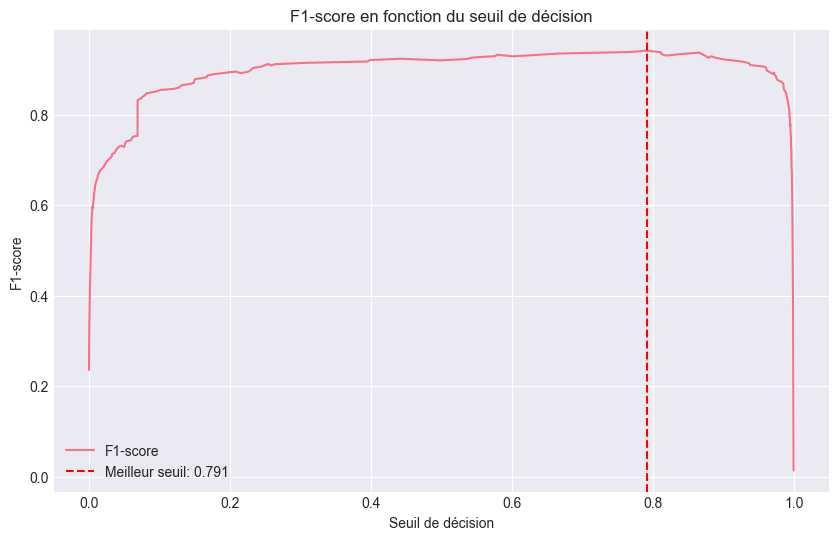

In [56]:
# 3. Optimisation du seuil de décision
from sklearn.metrics import precision_recall_curve, f1_score

# Obtenir les probabilités pour la classe spam
y_proba_spam = model.predict(X_test)[:, 1]

# Calculer precision/recall pour différents seuils
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_spam)

# Calculer F1-score pour chaque seuil
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Trouver le meilleur seuil
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Meilleur seuil: {best_threshold:.3f}")
print(f"F1-score avec meilleur seuil: {best_f1:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Meilleur seuil: {best_threshold:.3f}')
plt.xlabel('Seuil de décision')
plt.ylabel('F1-score')
plt.title('F1-score en fonction du seuil de décision')
plt.legend()
plt.grid(True)
plt.show()